In [1]:
import yaml
import glob
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Draw, AllChem
rdBase.DisableLog('rdApp.*')  # RDKitのエラーログを無効化
from rdkit.DataStructs import TanimotoSimilarity

from tdc import Evaluator as tdc_Evaluator

from mol_data import Mol_Data
from evaluator import Evaluator


In [2]:
class Island:
    def __init__(self,path,task):
        self.evaluator = Evaluator(task)
        self.all = []
        self.offsprings = []
        self.initial_population = self.load_population(os.path.join(path,"population/population_0G.yaml"))
        self.load(os.path.join(path,"offspring"))

    def load_population(self,yaml_file):
        with open(yaml_file, 'r', encoding='utf-8') as f:
            datas = yaml.safe_load(f)
            population = []
            for data in datas.values():

                self.all.append(data["smi"])

                if "inter_smi" in data:
                    population.append(Mol_Data(
                        Chem.MolFromSmiles(data["smi"]),
                        data["smi"],
                        self.evaluator.score(data["smi"]),
                        data["parent1_smi"],
                        data["parent2_smi"],
                        data["inter_smi"]))
                if "inter_smi" not in data:
                    population.append(Mol_Data(
                        Chem.MolFromSmiles(data["smi"]),
                        data["smi"],
                        self.evaluator.score(data["smi"]),
                        data["parent1_smi"],
                        data["parent2_smi"]))

            return population

    def load(self,offspring_dir):
        # 指定されたディレクトリ内で'offspring_'で始まるすべてのYAMLファイルを検索します。
        yaml_files = glob.glob(os.path.join(offspring_dir, 'offspring_*.yaml'))

        def get_generation_number(filepath):
            """
            ファイル名から世代番号を抽出するためのヘルパー関数です。
            """
            filename = os.path.basename(filepath)
            # ファイル名の形式は 'population_{世代番号}G.yaml' を想定しています。
            try:
                # 世代番号の文字列を抽出し、整数に変換します。
                gen_str = filename.split('_')[1].replace('G.yaml', '')
                return int(gen_str)
            except (IndexError, ValueError):
                # ファイル名が期待される形式でない場合は-1を返します。
                return -1

        # 世代番号に基づいてYAMLファイルをソートし、時系列順に処理できるようにします。
        yaml_files.sort(key=get_generation_number)

        print("Loading results ...")
        for yaml_file in tqdm(yaml_files):
            with open(yaml_file, 'r', encoding='utf-8') as f:
                offsprings = yaml.safe_load(f)
                for offspring in offsprings.values():
                    if offspring["smi"] in self.all: continue

                    if "inter_smi" in offspring:
                        self.offsprings.append(Mol_Data(
                            Chem.MolFromSmiles(offspring["smi"]),
                            offspring["smi"],
                            self.evaluator.score(offspring["smi"]),
                            offspring["parent1_smi"],
                            offspring["parent2_smi"],
                            offspring["inter_smi"]
                            ))
                    elif "inter_smi" not in offspring:
                        self.offsprings.append(Mol_Data(
                            Chem.MolFromSmiles(offspring["smi"]),
                            offspring["smi"],
                            self.evaluator.score(offspring["smi"]),
                            offspring["parent1_smi"],
                            offspring["parent2_smi"]
                            ))

                    self.all.append(offspring["smi"])

        print("Loading finished")
    
    

In [ ]:
diversity_evaluator = tdc_Evaluator(name = 'Diversity')

def sim_with_parents(mlc):
    sims = {}

    self_fp = AllChem.GetMorganFingerprintAsBitVect(mlc.mol, 2, nBits=1024)

    if mlc.parent1_smi != "":
        fp_parent1 = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(mlc.parent1_smi), 2, nBits=1024)
        sims["parent1"] = TanimotoSimilarity(fp_parent1,self_fp)
    if mlc.parent2_smi != "":
        fp_parent2 = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(mlc.parent2_smi), 2, nBits=1024)
        sims["parent2"] = TanimotoSimilarity(fp_parent2,self_fp)
    if mlc.inter_smi != "":
        fp_inter = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(mlc.inter_smi), 2, nBits=1024)
        sims["inter"] = TanimotoSimilarity(fp_inter,self_fp)
    return sims

def population_update(population,mlc):
        new = population[:]
        new.append(mlc)
        return sorted(new, reverse=True)[:len(population)]

def avg_scores(island):
    population = island.initial_population[:]
    scores = []
    for offspring in island.offsprings:
        population = population_update(population,offspring)
        scores.append(np.mean([mlc.score for mlc in population]))
    return scores

def diversities(island):
    population = island.initial_population[:]
    scores = []
    for offspring in tqdm(island.offsprings):
        population = population_update(population,offspring)
        smis = [mlc.smi for mlc in population]
        scores.append(diversity_evaluator(smis))
    return scores

def overall_diversities(islands):
    populations = [island.initial_population[:] for island in islands]
    for 
def parents_simiralities(island):
    scores = []
    for offspring in tqdm(island.offsprings):
        scores.append(max(sim_with_parents(offspring).values()))
    return scores

def calculate_population_similarity(population1, population2):
        """
        2つのpopulation間の類似度を「最大類似度の平均」を用いて計算します。
        具体的には、一方の集団の各個体について、もう一方の集団における最も類似度の高い個体との類似度（最大類似度）を求め、
        それらの平均値を取ります。これを双方向で行い、最終的に2つの平均値をさらに平均して返します。
        類似度計算にはMorganフィンガープリントとTanimoto係数を使用します。

        Args:
            population1 (list): Mol_Dataオブジェクトのリスト。
            population2 (list): Mol_Dataオブジェクトのリスト。

        Returns:
            float: 2つのpopulation間の平均最大類似度。
        """
        mols1 = [mol_data.mol for mol_data in population1 if mol_data.mol is not None]
        mols2 = [mol_data.mol for mol_data in population2 if mol_data.mol is not None]

        if not mols1 or not mols2:
            return 0.0

        fps1 = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols1]
        fps2 = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols2]

        def get_avg_max_similarity(fps_a, fps_b):
            total_max_similarity = 0
            if not fps_a or not fps_b:
                return 0.0
            
            for fp_a in fps_a:
                max_sim = 0
                for fp_b in fps_b:
                    sim = DataStructs.TanimotoSimilarity(fp_a, fp_b)
                    if sim > max_sim:
                        max_sim = sim
                total_max_similarity += max_sim
            return total_max_similarity / len(fps_a)

        avg_max_sim_1_to_2 = get_avg_max_similarity(fps1, fps2)
        avg_max_sim_2_to_1 = get_avg_max_similarity(fps2, fps1)

        return (avg_max_sim_1_to_2 + avg_max_sim_2_to_1) / 2.0

In [ ]:
biot5 = Island("results/freq1/BioT5","JNK3")
gemma = Island("results/freq1/Gemma","JNK3")
gpt = Island("results/freq1/GPT","JNK3")
qwen = Island("results/freq1/Qwen3","JNK3")

Found local copy...


Loading results ...


100%|██████████| 30/30 [00:53<00:00,  1.80s/it]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 30/30 [00:40<00:00,  1.36s/it]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 30/30 [00:42<00:00,  1.42s/it]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 30/30 [00:17<00:00,  1.70it/s]

Loading finished


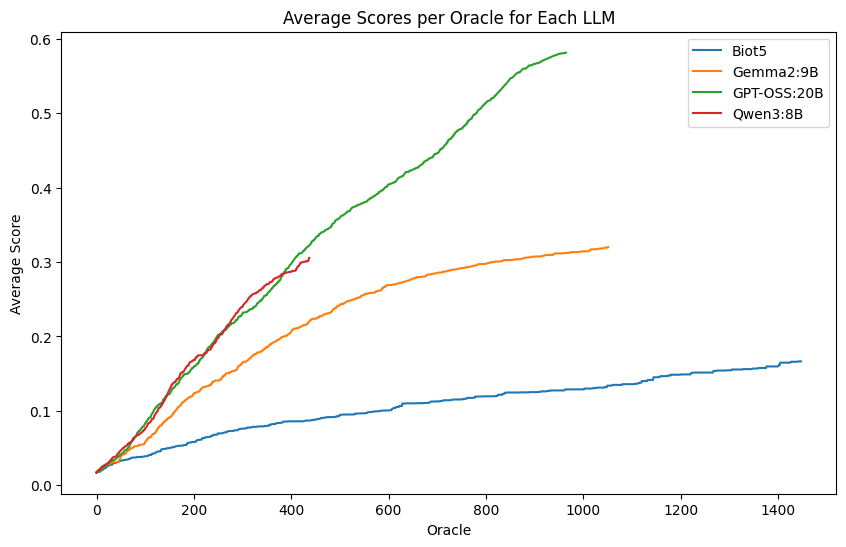

In [5]:
# Calculate avg_scores for each Island
islands = {
    "Biot5": biot5,
    #"DeepSeek-R1:8B": deepseek,
    #"DrugAssist": drugassist,
    #"GeminiAPI": gemini,
    "Gemma2:9B": gemma,
    "GPT-OSS:20B": gpt,
    "Qwen3:8B": qwen
}

avg_scores_dict = {name: avg_scores(island) for name, island in islands.items()}

# Plot the avg_scores
plt.figure(figsize=(10, 6))
for name, scores in avg_scores_dict.items():
    plt.plot(scores, label=name)

plt.xlabel("Oracle")
plt.ylabel("Average Score")
plt.title("Average Scores per Oracle for Each LLM")
plt.legend()
plt.show()

100%|██████████| 438/438 [00:34<00:00, 12.65it/s]


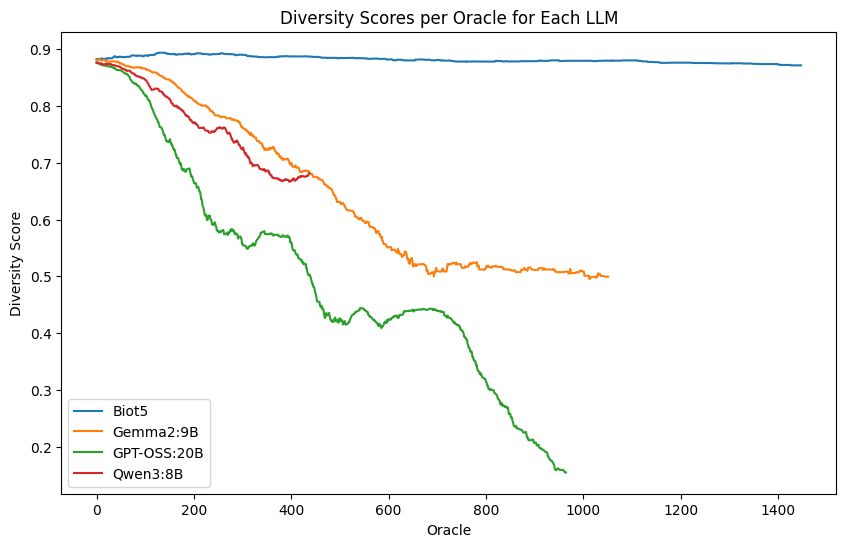

In [6]:
# Calculate diversities for each Island
diversities_dict = {name: diversities(island) for name, island in islands.items()}

# Plot the diversities
plt.figure(figsize=(10, 6))
for name, diversity_scores in diversities_dict.items():
    plt.plot(diversity_scores, label=name)

plt.xlabel("Oracle")
plt.ylabel("Diversity Score")
plt.title("Diversity Scores per Oracle for Each LLM")
plt.legend()
plt.show()

  0%|          | 0/1448 [00:00<?, ?it/s]

100%|██████████| 438/438 [00:00<00:00, 948.37it/s] 


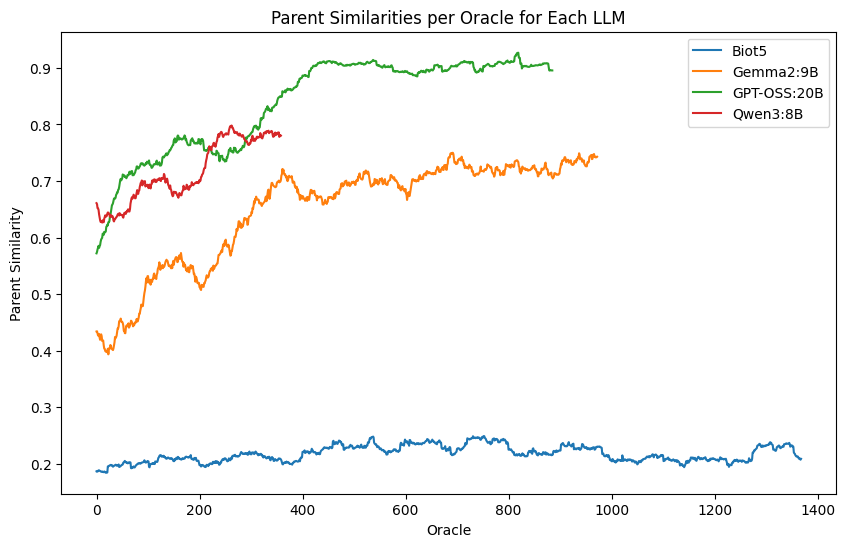

In [7]:
# Calculate parents_similarities for each Island
parents_similarities_dict = {name: np.convolve(parents_simiralities(island), np.ones(80)/80, mode='valid') for name, island in islands.items()}

# Plot the parents_similarities
plt.figure(figsize=(10, 6))
for name, similarities in parents_similarities_dict.items():
    plt.plot(similarities, label=name)

plt.xlabel("Oracle")
plt.ylabel("Parent Similarity")
plt.title("Parent Similarities per Oracle for Each LLM")
plt.legend()
plt.show()

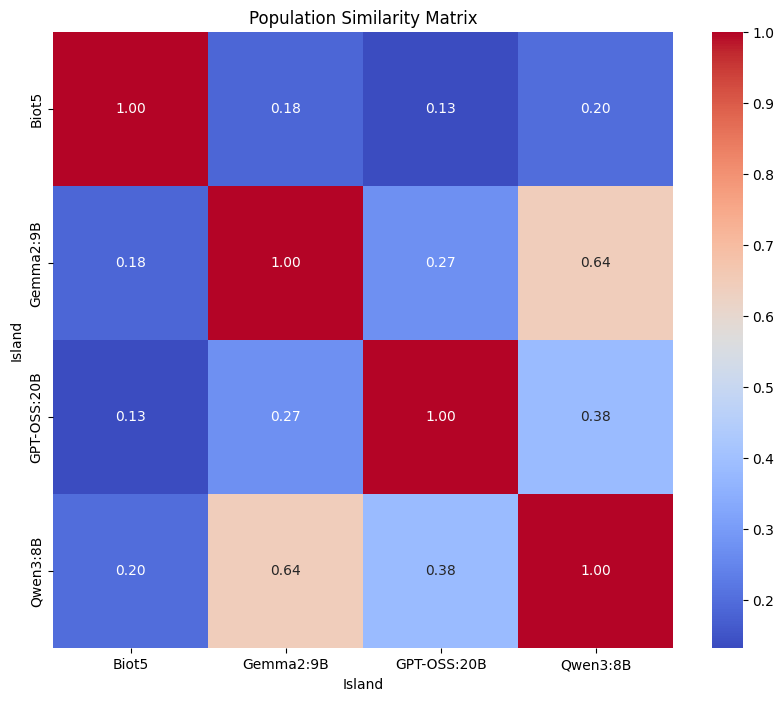

In [8]:
# Calculate the final populations for each island
final_populations = {}
for name, island in islands.items():
    population = island.initial_population[:]
    for offspring in island.offsprings:
        population = population_update(population, offspring)
    final_populations[name] = population

# Calculate the similarity matrix
island_names = list(islands.keys())
num_islands = len(island_names)
similarity_matrix = np.zeros((num_islands, num_islands))

for i in range(num_islands):
    for j in range(num_islands):
        if i <= j:  # Avoid redundant calculations
            similarity = calculate_population_similarity(final_populations[island_names[i]], final_populations[island_names[j]])
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity  # Symmetric matrix

# Plot the similarity matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, xticklabels=island_names, yticklabels=island_names, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Population Similarity Matrix")
plt.xlabel("Island")
plt.ylabel("Island")
plt.show()

Island: Biot5


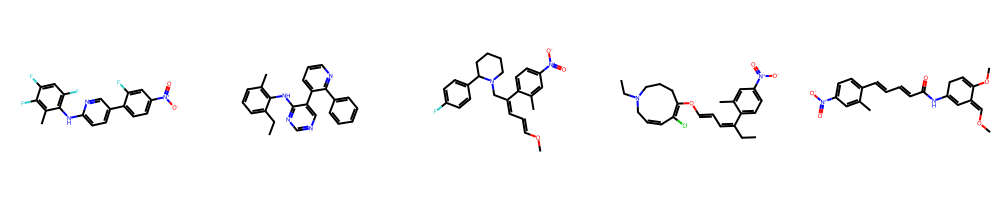

Island: Gemma2:9B


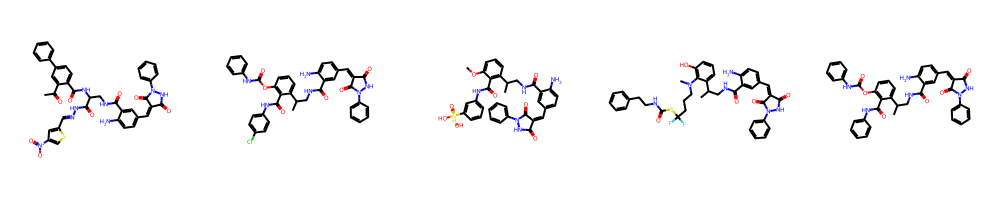

Island: GPT-OSS:20B


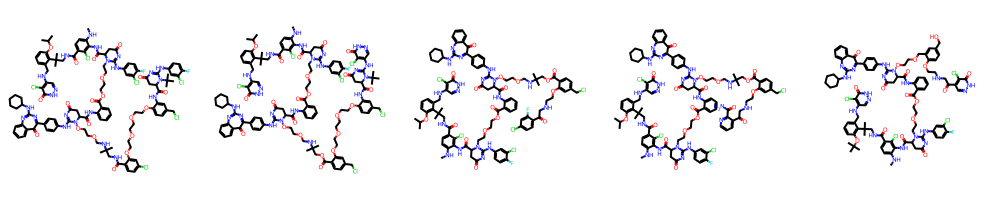

Island: Qwen3:8B


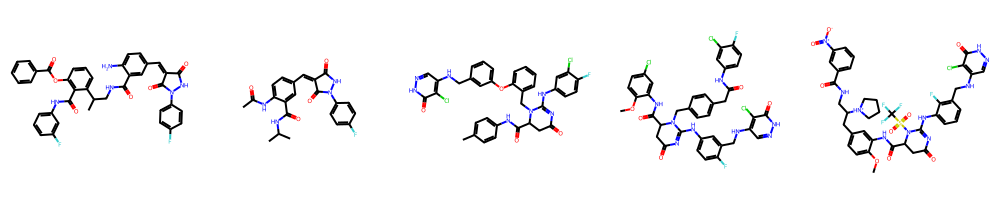

In [9]:
import random
from rdkit.Chem import Draw

# ランダムに分子を選択して描画する関数
def draw_random_molecules(final_populations, num_molecules=5):
    for name, population in final_populations.items():
        # ランダムに分子を選択
        selected_molecules = random.sample([mol_data.mol for mol_data in population if mol_data.mol is not None], num_molecules)
        
        # 分子を描画
        print(f"Island: {name}")
        img = Draw.MolsToGridImage(selected_molecules, molsPerRow=5, subImgSize=(200, 200))
        display(img)

# 各アイランドの最終populationからランダムに5個の分子を描画
draw_random_molecules(final_populations, num_molecules=5)

Island: Biot5


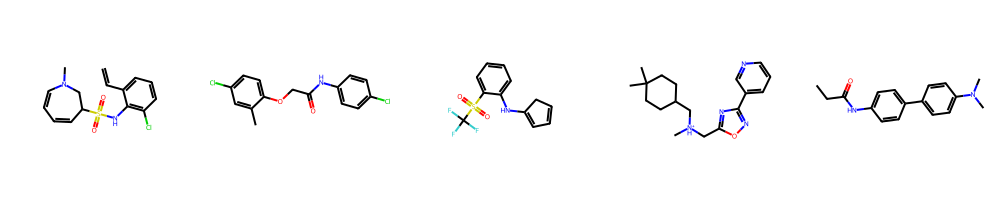

Island: DeepSeek-R1:8B


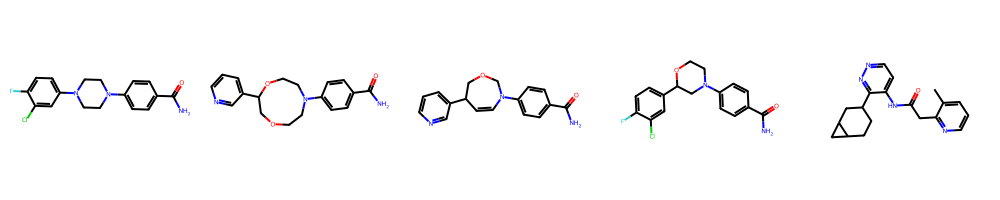

Island: DrugAssist


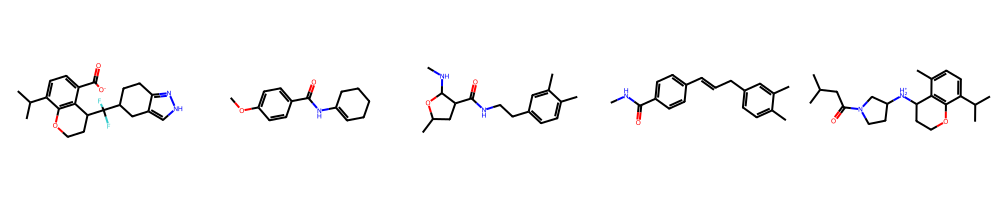

Island: GeminiAPI


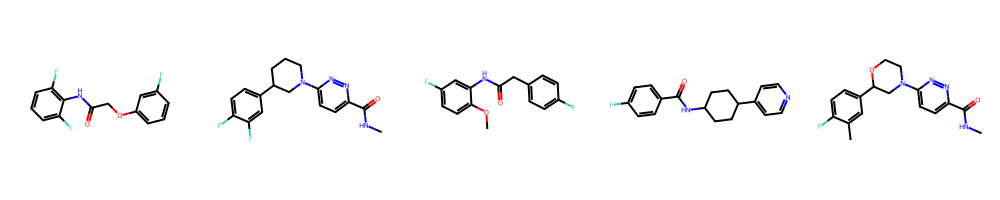

Island: Gemma2:9B


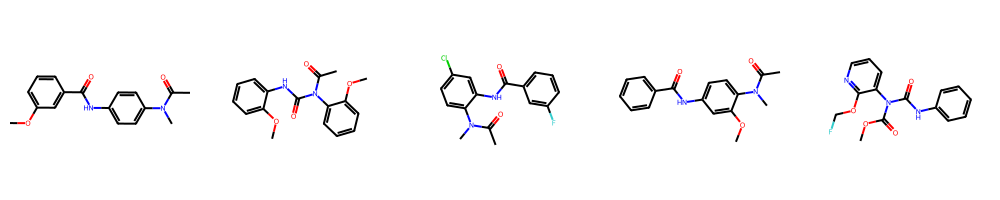

Island: GPT-OSS:20B


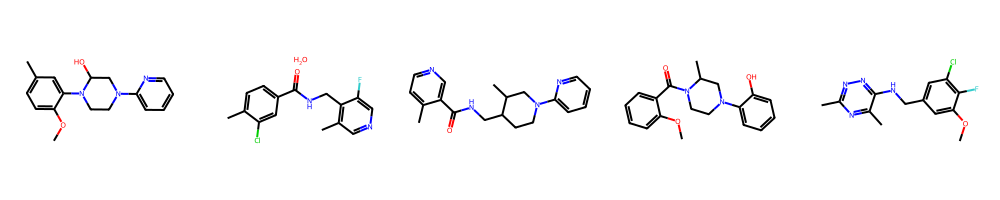

Island: Qwen3:8B


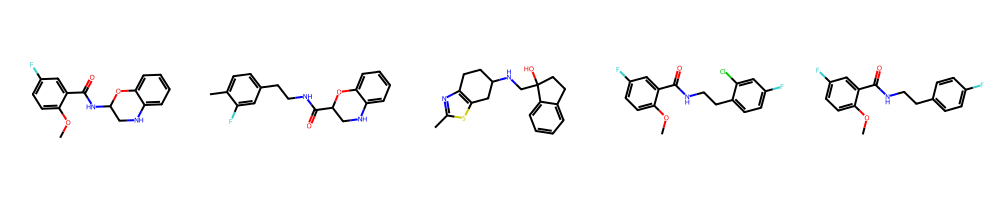

In [14]:
import random
from rdkit.Chem import Draw

# ランダムに分子を選択して描画する関数
def draw_random_molecules(final_populations, num_molecules=1):
    for name, population in final_populations.items():
        # ランダムに分子を選択
        selected_molecules = random.sample([mol_data.mol for mol_data in population if mol_data.mol is not None], num_molecules)
        
        # 分子を描画
        print(f"Island: {name}")
        img = Draw.MolsToGridImage(selected_molecules, molsPerRow=5, subImgSize=(200, 200))
        display(img)

# 各アイランドの最終populationからランダムに5個の分子を描画
draw_random_molecules(final_populations, num_molecules=5)